# Sidebar
This is a throwaway notebook used in combination with the "part 2" notebook to preprocess data for second stage test.

In [1]:
import mspasspy.client as msc
mspass_client=msc.Client()
dbclient=mspass_client.get_database_client()
#dbclient.drop_database('MCXcorTesting')
cursor=dbclient.list_databases()
for doc in cursor:
    print(doc['name'])

MCXcorTesting
admin
config
local
mspass


In [2]:
dbclient.drop_database("MCXcorTestdata2")

In [2]:
db=dbclient.get_database('MCXcorTesting')
cursor=db.list_collections()
for doc in cursor:
    print(doc['name'])

abortions
cemetery
wf_miniseed
source
channel
history_object
site
history_global
wf_Seismogram
fs.chunks
wf_TimeSeries
fs.files
elog


In [3]:
from bson import json_util
doc=db.wf_miniseed.find_one()
print(json_util.dumps(doc,indent=2))

{
  "_id": {
    "$oid": "673376108ccc001f816b1f22"
  },
  "sta": "034A",
  "net": "TA",
  "chan": "BHE",
  "sampling_rate": 40.0,
  "delta": 0.025,
  "starttime": 1299825050.0,
  "last_packet_time": 1299827429.775,
  "foff": 0,
  "nbytes": 192512,
  "npts": 96001,
  "endtime": 1299827450.0,
  "storage_mode": "file",
  "format": "mseed",
  "dir": "/N/slate/pavlis/test_MCXcor/wf",
  "dfile": "Event_13.msd",
  "time_standard": "UTC",
  "channel_endtime": 1321549500.0,
  "channel_hang": 89.1,
  "channel_id": {
    "$oid": "673363292e6e2f5c8a107632"
  },
  "channel_starttime": 1262908800.0,
  "channel_vang": 90.0,
  "site_endtime": 1321574399.0,
  "site_id": {
    "$oid": "673363292e6e2f5c8a107632"
  },
  "site_starttime": 1262908800.0
}


In [8]:
db.drop_collection('fs.chunks')
db.drop_collection('fs.files')
db.drop_collection('wf_TimeSeries')
db.drop_collection('abortions')
db.drop_collection('elog')
db.drop_collection('cemetery')
db.drop_collection('wf_Seismogram')
db.drop_collection('wf_miniseed')

{'nIndexesWas': 1, 'ns': 'MCXcorTesting.wf_miniseed', 'ok': 1.0}

In [9]:
n=db.arrival_xcor.count_documents({})
print(n)
doc=db.arrival_xcor.find_one()
print(doc)

791
{'_id': ObjectId('67261b7c019821bf96966fc4'), 'Ptime_xcor': 1296305435.6491215, 'beam_correlation': 0.3232704658077392, 'beam_coherence': 0.10243909484450375, 'beam_relative_amplitude': 0.06064227891489306, 'Presidual': 0.6877872943878174, 'Ptime': 1296305434.3990784, 'Pmeasured': 1296305435.0868657, 'wf_Seismogram_id': ObjectId('6724c68af96c938a276e6150')}


In [12]:
from mspasspy.util.seismic import print_metadata
n=db.wf_TimeSeries.count_documents({"data_tag" : "Pbeam"})
print(n)
doc=db.wf_TimeSeries.find_one({"data_tag" : "Pbeam"})
print_metadata(doc)

11
{
  "_id": {
    "$oid": "67261b7c019821bf96966fd9"
  },
  "sampling_rate": 20.0,
  "npts": 12001,
  "tmatrix": [
    0.09282127715420802,
    0.4913086713131183,
    0.0,
    -0.47022365472091876,
    0.08883775664423046,
    0.09808142912256734,
    0.1652168798492583,
    -0.031213863484342737,
    0.4926373925306883
  ],
  "endtime": 500.00602555274963,
  "time_standard": "Relative",
  "sta": "J05D",
  "channel_id": {
    "$oid": "6724b8573d3b9fc0fc6c8434"
  },
  "epicentral_distance": 79.47258327983508,
  "elog_id": {
    "$oid": "67261b7c019821bf96966fd8"
  },
  "seaz": 289.8548274548594,
  "Parrival": {
    "low_f_band_edge": 0.4838064774090364,
    "high_f_band_edge": 3.0907636945221912,
    "low_f_band_edge_snr": 1.4698252288588802,
    "high_f_band_edge_snr": 1.2102483830164197,
    "spectrum_frequency_range": 10.0,
    "bandwidth": 16.1078824720375,
    "bandwidth_fraction": 0.2606957217113155,
    "filter_type": "bandpass",
    "filter_number_poles": 3,
    "mean_snr": 9

In [19]:
# this needs to be changed in MCXcor code to have the actual band data set in beam 
# for now take the one cloned from the initial beam
doc=beam['Parrival']
fl=doc['low_f_band_edge']
fh=doc['high_f_band_edge']

In [22]:
# experimental gather reader driven by beam
from mspasspy.algorithms.basic import ator
from mspasspy.ccore.seismic import SeismogramEnsemble
from mspasspy.algorithms.signals import filter
doc=db.wf_TimeSeries.find_one({"data_tag" : "Pbeam"})
beam=db.read_data(doc,collection="wf_TimeSeries")
idlist=doc["wflist"]
e = SeismogramEnsemble(len(idlist))
for wfid in idlist:
    d = db.read_data(wfid,collection="wf_Seismogram")
    arrdoc = db.arrival_xcor.find_one({"wf_Seismogram_id" : wfid})
    Ptime = arrdoc["Pmeasured"]
    d = ator(d,Ptime)
    e.member.append(d)
e = filter(e,type='bandpass',freqmin=fl,freqmax=fh)
e.set_live()

True

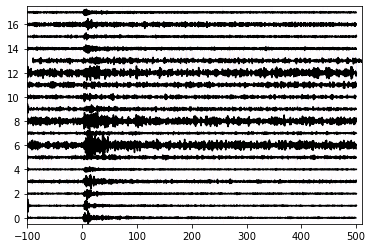

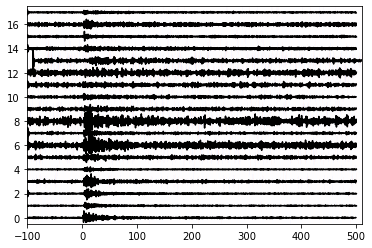

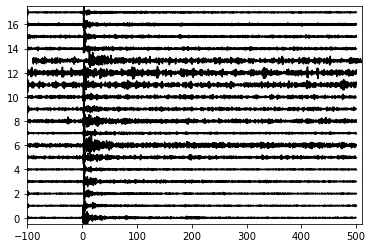

In [23]:
from mspasspy.graphics import SeismicPlotter
plotter=SeismicPlotter(normalize=True)
plotter.plot(e)

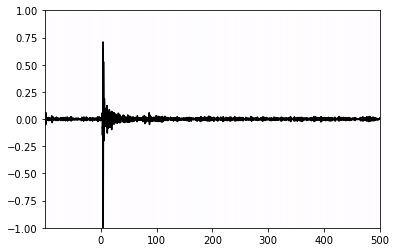

In [18]:
plotter.plot(beam)

In [24]:
n=db.abortions.count_documents({})
print("abortions collection size=",n)
n=db.cemetery.count_documents({})
print("cememetery collection size=",n)
n=db.elog.count_documents({})
print("elog collection size=",n)

abortions collection size= 3891
cememetery collection size= 21696
elog collection size= 43838


In [25]:
doc=db.elog.find_one()
print_metadata(doc)

{
  "_id": {
    "$oid": "6724c1d0f96c938a276b2004"
  },
  "logdata": [
    {
      "job_id": 0,
      "algorithm": "resample",
      "badness": "ErrorSeverity.Complaint",
      "error_message": "sampling_rate inconsistent with 1/dt; updating to 1/dt",
      "process_id": 494474
    }
  ],
  "data_tag": "serial_preprocessed",
  "wf_TimeSeries_id": {
    "$oid": "6724c1c39ffe9888300bf1bd"
  }
}


In [28]:
messages=set()
algorithms=set()
cursor=db.elog.find({})
for doc in cursor:
    entries=doc['logdata']
    for e in entries:
        messages.add(e['error_message'])
        algorithms.add(e['algorithm'])
print("Number of unique messages=",len(messages))
print("Number of unique algorithm postings=",len(algorithms))

Number of unique messages= 249
Number of unique algorithm postings= 4


In [29]:
print("Algorithms posting messages:")
print(algorithms)
print("Unique messages")
for m in messages:
    print(m)

Algorithms posting messages:
{'resample', 'WindowDataAtomic', 'Database._read_data_from_dfile:  ', 'OriginTimeMatcher.find_one'}
Unique messages
Window start time is less than data start time
Window range: -100.50629425048828 < t < 500.00061535835266  Data range:  -99.99938464164734 < t < 500.00061535835266
Setting window start time to data start time=-99.99938464164734

Window start time is less than data start time
Window range: -100.31914162635803 < t < 500.0031199455261  Data range:  -99.99688005447388 < t < 500.0031199455261
Setting window start time to data start time=-99.99688005447388

Window start time is less than data start time
Window range: -100.0804009437561 < t < 500.0002131462097  Data range:  -99.99978685379028 < t < 500.0002131462097
Setting window start time to data start time=-99.99978685379028

Window end time is after data end time
Window range: -99.99938464164734 < t < 500.043705701828  Data range:  -99.99938464164734 < t < 500.00061535835266
Setting window end t

In [9]:
from mspasspy.util.seismic import print_metadata
doc=db.abortions.find_one()
print_metadata(doc)


{
  "_id": {
    "$oid": "671b7ca86b71fb2bde9d5380"
  },
  "tombstone": [
    {
      "channel_vang": 90.0,
      "_id": {
        "$oid": "671b7baa9caa327d131171b0"
      },
      "nbytes": 12288,
      "npts": 16420,
      "chan": "BHE",
      "channel_starttime": 1292371200.0,
      "channel_elev": 0.294,
      "net": "TA",
      "sampling_rate": 40.0,
      "sta": "S38A",
      "last_packet_time": 1314210536.675,
      "channel_id": {
        "$oid": "671b688293e1c7ba4672ae26"
      },
      "channel_hang": 92.5,
      "starttime": 1314210260.5249999,
      "format": "mseed",
      "foff": 115153408,
      "is_abortion": true,
      "delta": 0.025,
      "channel_lat": 37.630402,
      "endtime": 1314210670.9999998,
      "storage_mode": "file",
      "time_standard": "UTC",
      "channel_endtime": 1343584800.0,
      "dfile": "Event_6.msd",
      "dir": "/home/pavlis/data/test_MCXcor/wf",
      "channel_lon": -93.907799,
      "site_starttime": 1292371200.0,
      "site_id": {
  

In [10]:
cursor=db.elog.find({}).limit(5)
for doc in cursor:
    print_metadata(doc)

{
  "_id": {
    "$oid": "671b7bb76b71fb2bde9cdbdf"
  },
  "logdata": [
    {
      "job_id": 0,
      "algorithm": "OriginTimeMatcher.find_one",
      "badness": "ErrorSeverity.Complaint",
      "error_message": "found 2 matches.  Returned first one found.  You should use find instead of find_one if the match is not unique",
      "process_id": 261320
    },
    {
      "job_id": 0,
      "algorithm": "resample",
      "badness": "ErrorSeverity.Complaint",
      "error_message": "sampling_rate inconsistent with 1/dt; updating to 1/dt",
      "process_id": 261320
    }
  ],
  "data_tag": "serial_preprocessed",
  "wf_TimeSeries_id": {
    "$oid": "671b7ba9c0bf635eef4ff0df"
  }
}
{
  "_id": {
    "$oid": "671b7bb76b71fb2bde9cdbe3"
  },
  "logdata": [
    {
      "job_id": 0,
      "algorithm": "OriginTimeMatcher.find_one",
      "badness": "ErrorSeverity.Complaint",
      "error_message": "found 2 matches.  Returned first one found.  You should use find instead of find_one if the match i

In [8]:
ne = db.elog.count_documents({})
print(ne)

57192


In [15]:
nwf=db.wf_TimeSeries.count_documents({})
print('Number of TimeSeries documents=',nwf)

Number of TimeSeries documents= 28158


In [6]:
n=db.wf_Seismogram.count_documents({})
print("total number of seismogram objects=",n)

total number of seismogram objects= 26834


In [5]:
srcidlist=db.wf_Seismogram.distinct('source_id')
for srcid in srcidlist:
    query={'source_id' : srcid, 'data_tag' : 'preprocessed'}
    n = db.wf_Seismogram.count_documents(query)
    print(srcid,n)

671b8d82c94626ec13f5821e 0
671b8d82c94626ec13f5821f 429
671b8d82c94626ec13f58220 0
671b8d82c94626ec13f58221 0
671b8d82c94626ec13f58222 0
671b8d82c94626ec13f58223 17
671b8d82c94626ec13f58224 0
671b8d82c94626ec13f58225 0
671b8d82c94626ec13f58226 0
671b8d82c94626ec13f58227 1
671b8d82c94626ec13f58228 7
671b8d82c94626ec13f58229 0
671b8d82c94626ec13f5822a 0
671b8d82c94626ec13f5822b 0
671b8d82c94626ec13f5822c 0
671b8d82c94626ec13f5822d 0
671b8d82c94626ec13f5822e 0
671b8d82c94626ec13f5822f 0
671b8d82c94626ec13f58230 0
671b8d82c94626ec13f58231 0
671b8d82c94626ec13f58232 0
671b8d82c94626ec13f58233 0
671b8d82c94626ec13f58234 0
671b8d82c94626ec13f58235 12
671b8d82c94626ec13f58236 0
671b8d82c94626ec13f58237 0
671b8d82c94626ec13f58238 0
671b8d82c94626ec13f58239 0
671b8d82c94626ec13f5823a 0
671b8d82c94626ec13f5823b 0
671b8d82c94626ec13f5823c 0
671b8d82c94626ec13f5823d 0
671b8d82c94626ec13f5823e 0
671b8d82c94626ec13f5823f 27
671b8d82c94626ec13f58240 444
671b8d82c94626ec13f58241 358
671b8d82c94626ec13f

In [4]:
# used to study a doc that is causing an exception
from bson import ObjectId, json_util
sid = ObjectId("6718c98d99dcfea4bcaf838e")
sta = "Z41A"
query={'source_id' : sid, 'sta' : sta}
doc = db.wf_Seismogram.find_one(query)
print(json_util.dumps(doc,indent=2))

{
  "_id": {
    "$oid": "6718e2b499dcfea4bcb54a3f"
  },
  "is_abortion": false,
  "nbytes": 155648,
  "dir": "/home/wf",
  "npts": 12001,
  "processing": [
    "ObsPy 1.4.1: detrend(options={}::type='constant')",
    "ObsPy 1.4.1: filter(options={'freqmin': 0.01, 'freqmax': 2.0, 'zerophase': False}::type='bandpass')"
  ],
  "time_standard": "UTC",
  "rayp_P": 265.2895023923875,
  "delta": 0.05,
  "format": "mseed",
  "dfile": "Event_13.msd",
  "data_tag": "serial_preprocessed",
  "net": "TA",
  "elog_id": {
    "$oid": "6718cdd199dcfea4bcb0e578"
  },
  "sampling_rate": 20.0,
  "starttime": 1299825434.05,
  "gridfs_id": {
    "$oid": "6718e2a199dcfea4bcb535c3"
  },
  "site_id": {
    "$oid": "6718c9ef99dcfea4bcaf91a8"
  },
  "sta": "Z41A",
  "seaz": 318.4429056186661,
  "Ptime": 1299825534.0310447,
  "chan": "BHZ",
  "endtime": 1299826034.05,
  "channel_id": {
    "$oid": "6718c9ef99dcfea4bcaf91ac"
  },
  "source_id": {
    "$oid": "6718c98d99dcfea4bcaf838e"
  },
  "foff": 210807808,
 

In [5]:
d=db.read_data(doc,collection='wf_Seismogram')

In [8]:
x=d.elog.get_error_log()
print(x)
print(d)

[LogData({'job_id': 0, 'p_id': 130150, 'algorithm': 'Database._read_data_from_gridfs', 'message': 'Size mismatch in sample data.\nNumber of points in gridfs file=%d but wf document expected %d', 'badness': ErrorSeverity.Invalid})]
{'Ptime': 1299825534.031045, 'Stime': 1299826191.200123, '_id': ObjectId('6718e2b499dcfea4bcb54a3f'), 'calib': 1.000000, 'chan': 'BHZ', 'channel_id': ObjectId('6718c9ef99dcfea4bcaf91ac'), 'data_tag': 'serial_preprocessed', 'delta': 0.050000, 'dfile': 'Event_13.msd', 'dir': '/home/wf', 'elog_id': ObjectId('6718cdd199dcfea4bcb0e578'), 'endtime': 1299826034.050000, 'epicentral_distance': 91.136449, 'esaz': 44.768701, 'foff': 210807808, 'format': 'mseed', 'gridfs_id': ObjectId('6718e2a199dcfea4bcb535c3'), 'is_abortion': True, 'last_packet_time': 1299827434.825000, 'nbytes': 155648, 'net': 'TA', 'npts': 12001, 'processing': ["ObsPy 1.4.1: detrend(options={}::type='constant')", "ObsPy 1.4.1: filter(options={'freqmin': 0.01, 'freqmax': 2.0, 'zerophase': False}::type

In [4]:
dirlist=db.wf_miniseed.distinct('dir')
print(dirlist)

['/home/pavlis/data/test_MCXcor/wf', '/home/pavlis/data/test_MCXcor/wf_MCXcor', '/home/wf', '/home/wf_MCXcor']


Three should be 50 events in this database.  33 new and 17 from the 2024 short course set

In [5]:
n=db.source.count_documents({})
print(n)

50


In [10]:
# verify id cross references are intact
nwfms = db.wf_miniseed.count_documents({})
print("Number of miniseed documents=",nwfms)
nsite=db.wf_miniseed.count_documents({'site_id' : {'$exists' : True}})
print("Number of doc with site_id set = ",nsite)
nchannel=db.wf_miniseed.count_documents({'channel_id' : {'$exists' : True}})
print("Number of doc with channel_id set = ",nchannel)

Number of miniseed documents= 68718
Number of doc with site_id set =  63207
Number of doc with channel_id set =  62886


Hmmm = a lot of metadata problems at the moment.  Let's look at a few:

In [11]:
import pandas as pd
doclist=[]
cursor = db.wf_miniseed.find({'channel_id' : {'$exists' : False}}).limit(20)
for doc in cursor:
    doclist.append(doc)
df = pd.DataFrame(doclist)
print(df)

                         _id   sta net chan  sampling_rate  delta  \
0   6703bb217d652ac182213b15  140A  TA  BHE           40.0  0.025   
1   6703bb217d652ac182213b16  140A  TA  BHN           40.0  0.025   
2   6703bb217d652ac182213b17  140A  TA  BHZ           40.0  0.025   
3   6703bb217d652ac182213b18  141A  TA  BHE           40.0  0.025   
4   6703bb217d652ac182213b19  141A  TA  BHN           40.0  0.025   
5   6703bb217d652ac182213b1a  141A  TA  BHZ           40.0  0.025   
6   6703bb217d652ac182213b1b  142A  TA  BHE           40.0  0.025   
7   6703bb217d652ac182213b1c  142A  TA  BHN           40.0  0.025   
8   6703bb217d652ac182213b1d  142A  TA  BHZ           40.0  0.025   
9   6703bb217d652ac182213b1e  143A  TA  BHE           40.0  0.025   
10  6703bb217d652ac182213b1f  143A  TA  BHN           40.0  0.025   
11  6703bb217d652ac182213b20  143A  TA  BHZ           40.0  0.025   
12  6703bb217d652ac182213b22  144A  TA  BHE           40.0  0.025   
13  6703bb217d652ac182213b24  144A

Hypothesis 1:   time range issue?

In [12]:
from obspy import UTCDateTime
for doc in doclist:
    print(doc['sta'],doc['chan'],UTCDateTime(doc['starttime']),UTCDateTime(doc['endtime']))

140A BHE 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
140A BHN 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
140A BHZ 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
141A BHE 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
141A BHN 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
141A BHZ 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
142A BHE 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
142A BHN 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:37.975000Z
142A BHZ 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
143A BHE 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
143A BHN 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
143A BHZ 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
144A BHE 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
144A BHN 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
144A BHZ 2011-06-24T03:14:38.000000Z 2011-06-24T03:54:38.000000Z
145A BHE 2011-06-24T03:14

In [15]:
cursor=db.channel.find({'sta':'141A','chan':'BHE'})
for doc in cursor:
    print(UTCDateTime(doc['starttime'],doc['endtime']))

In [16]:
n=db.channel.count_documents({'sta' : '140A'})
print(n)

0


In [19]:
nstawf=db.wf_miniseed.distinct('sta')
nstachan=db.channel.distinct('sta')
print(len(nstawf),len(nstachan))

644 646


In [21]:
# find all sta that have a cross reference problem - count occurences 
stations = dict()
cursor = db.wf_miniseed.find({'channel_id' : {'$exists' : False}})
for doc in cursor:
    sta = doc['sta']
    if sta in stations:
        stations[sta] = stations[sta] + 1
    else:
        stations[sta]=1
for k in stations:
    print(k,stations[k])

140A 51
141A 51
142A 51
143A 51
144A 39
145A 39
146A 39
147A 36
240A 51
241A 51
242A 51
243A 51
236A 27
244A 39
245A 39
246A 39
247A 36
248A 36
336A 51
341A 51
342A 51
343A 51
344A 39
345A 39
337A 24
346A 39
347A 39
348A 39
441A 51
438A 48
442A 51
443A 51
444A 48
445A 48
446A 39
447A 39
448A 36
541A 51
542A 51
543A 51
544A 51
545A 39
546A 39
645A 39
646A 39
638A 48
C40A 12
D41A 15
E38A 18
E39A 15
E40A 15
E41A 15
E42A 15
E43A 15
E44A 12
E45A 12
F37A 18
F38A 18
F39A 15
F40A 18
F41A 18
F42A 15
F43A 15
F44A 12
F45A 12
F46A 12
G38A 27
G39A 27
G40A 27
G41A 27
G42A 12
G43A 15
H17A 21
H32A 12
H38A 27
H39A 27
H40A 27
H41A 27
H42A 12
H43A 12
I34A 36
I39A 27
I40A 27
I41A 27
I42A 12
I43A 12
J39A 36
J40A 36
J41A 36
J42A 12
J43A 12
K39A 36
K40A 36
K41A 36
K42A 12
K43A 12
L39A 36
L40A 36
L41A 36
L42A 3
L43A 12
L44A 12
M39A 36
M40A 18
M41A 27
M42A 27
M43A 6
M44A 9
M45A 6
M46A 6
MDND 27
N40A 18
N41A 21
N42A 27
N43A 3
N44A 12
N45A 12
N46A 12
O41A 36
O42A 36
O43A 27
O44A 12
O45A 12
O47A 9
P39B 36
P41A 36

In [22]:
len(stations)

215

Surprising results - let's experiment with web service retrievals and look at the Inventory from some of the above stations.

In [23]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
client=Client("IRIS")

In [25]:
ts=UTCDateTime('2010-01-01T00:00:00.0')
starttime=ts
te=UTCDateTime('2013-01-01T00:00:00.0')
endtime=te
inv=client.get_stations(network='TA',starttime=starttime,endtime=endtime,
                        format='xml',sta='140A',channel='BH?',level='response')
print(inv)

Inventory created at 2024-10-22T11:14:59.021700Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?station=140A&startti...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			TA
		Stations (1):
			TA.140A (Cam and Jess, Hughton, LA, USA)
		Channels (3):
			TA.140A..BHZ, TA.140A..BHN, TA.140A..BHE


Ahh - bug in the part2 notebook - used wrong endtime

In [5]:
query={'Ptime' : {'$exists' : 1},'data_tag' : 'serial_preprocessed'}
stalist=db.wf_Seismogram.find(query).distinct('sta')
print(stalist)

['A04D', 'B05D', 'C06D', 'D03D', 'D04D', 'E04D', 'F04D', 'F05D', 'G03D', 'G05D', 'H04D', 'I02D', 'I03D', 'I04A', 'I05D', 'J01D', 'J04D', 'J05D', 'K02D', 'K04D', 'L02D', 'L04D', 'M02C', 'M04C', 'N02D', 'O02D', 'O03D']


In [6]:
for sta in stalist:
    query['sta']=sta
    n=db.wf_Seismogram.count_documents(query)
    print(sta,n)

A04D 1
B05D 1
C06D 1
D03D 1
D04D 1
E04D 1
F04D 1
F05D 1
G03D 1
G05D 1
H04D 1
I02D 1
I03D 1
I04A 1
I05D 1
J01D 1
J04D 1
J05D 1
K02D 1
K04D 1
L02D 1
L04D 1
M02C 1
M04C 1
N02D 1
O02D 1
O03D 1


In [30]:
#cleanup to rerun align and stack with changes
idlist=[]
query={'data_tag' : 'Pbeam'}
print("number of beam traces to be deleted =",db.wf_TimeSeries.count_documents(query))
cursor=db.wf_TimeSeries.find(query)
for doc in cursor:
    wfid = doc['_id']
    db.delete_data(wfid,"TimeSeries")
n=db.wf_TimeSeries.count_documents(query)
print("Number remaining after delete operation=",n)

number of beam traces to be deleted = 11
Number remaining after delete operation= 0


In [31]:
db.drop_collection('arrival_xcor')

{'nIndexesWas': 1, 'ns': 'MCXcorTesting.arrival_xcor', 'ok': 1.0}

In [32]:
query1={'data_tag' : 'serial_preprocessed'}
query2={'data_tag' : 'preprocessed'}
srcidlist = db.wf_Seismogram.distinct('source_id')
print('n_raw n_edited')
for srcid in srcidlist:
    query1['source_id']=srcid
    query2['source_id']=srcid
    n1=db.wf_Seismogram.count_documents(query1)
    n2=db.wf_Seismogram.count_documents(query2)
    print(n1,n2)

n_raw n_edited
69 0
211 18
429 421
414 0
377 0
22 7
373 0
11 0
73 5
415 13
388 0
394 0
393 0
402 0
184 29
388 0
132 3
56 2
393 0
393 0
393 0
393 0
13 0
431 93
393 0
35 23
437 27
444 431
441 356
437 84
432 88
436 40
439 438
446 38
445 39
437 412
437 111
428 424
429 411
437 119
437 436
435 417
